# Atlas Renovável do Nordeste — Análise Exploratória de Dados

Este notebook realiza a Análise Exploratória de Dados (EDA) do dataset consolidado de estações automáticas do INMET para os 9 estados do Nordeste, período 2022–2025.

**Fonte:** INMET — Instituto Nacional de Meteorologia  
**Dataset:** `data/processed/inmet_medias_estacoes.csv`  
**Variáveis principais:** Irradiação solar média (kWh/m²/dia) e velocidade do vento médio (m/s) por estação.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

PALETTE = 'Set2'
ESTADOS_NE = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregamento e Visão Geral dos Dados

In [2]:
df = pd.read_csv('../data/processed/inmet_medias_estacoes.csv')

# Calcular IP-NE conforme metodologia Ferreira et al. (2023)
solar_min, solar_max = df['SOLAR_IRRAD_kwh_m2_dia'].min(), df['SOLAR_IRRAD_kwh_m2_dia'].max()
wind_min,  wind_max  = df['WIND_SPEED_ms'].min(),           df['WIND_SPEED_ms'].max()

df['SOLAR_NORM'] = (df['SOLAR_IRRAD_kwh_m2_dia'] - solar_min) / (solar_max - solar_min)
df['WIND_NORM']  = (df['WIND_SPEED_ms']  - wind_min)  / (wind_max  - wind_min)
df['IP_NE']      = np.sqrt(df['SOLAR_NORM']**2 + df['WIND_NORM']**2)

print(f'Dimensões do dataset: {df.shape[0]} estações × {df.shape[1]} colunas')
print(f'Estados representados: {sorted(df["UF"].unique())}')
print()
df.head()

Dimensões do dataset: 134 estações × 13 colunas
Estados representados: ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']



,COD_WMO,UF,ESTACAO,LAT,LON,ALT,SOLAR_IRRAD_kwh_m2_dia,WIND_SPEED_ms,anos_disponiveis,dias_validos_total,SOLAR_NORM,WIND_NORM,IP_NE
0,A353,AL,ARAPIRACA,-9.804444,-36.619167,236.84,4.5299,2.1863,4,764,0.512664,0.248477,0.569706
1,A355,AL,CORURIPE,-10.128611,-36.286389,82.39,4.5111,2.3077,4,1303,0.508625,0.264015,0.573065
2,A303,AL,MACEIO,-9.551111,-35.770278,84.12,4.8287,2.4474,4,1409,0.576851,0.281895,0.642045
3,A327,AL,PALMEIRA DOS INDIOS,-9.420278,-36.620278,278.01,4.6692,1.3826,4,1208,0.542588,0.145613,0.561787
4,A323,AL,PAO DE ACUCAR,-9.749167,-37.430833,20.83,5.4434,1.5646,4,1164,0.708900,0.168906,0.728744


In [3]:
print('=== Estatísticas Descritivas ===')
desc = df[['SOLAR_IRRAD_kwh_m2_dia', 'WIND_SPEED_ms', 'ALT', 'IP_NE']].describe().round(3)
desc.index.name = None
desc.columns = ['Solar (kWh/m²/dia)', 'Vento (m/s)', 'Altitude (m)', 'IP-NE']
display(desc)

=== Estatísticas Descritivas ===


,Solar (kWh/m²/dia),Vento (m/s),Altitude (m),IP-NE
count,134.000,134.000,134.000,134.000
mean,4.600,2.115,292.042,0.593
std,0.820,0.939,232.368,0.172
min,2.143,0.245,3.720,0.230
25%,4.164,1.487,95.840,0.486
50%,4.690,2.084,255.555,0.597
75%,5.068,2.638,430.250,0.691
max,6.798,8.058,1283.950,1.254


## Visualização 1 — Distribuição de Estações por Estado

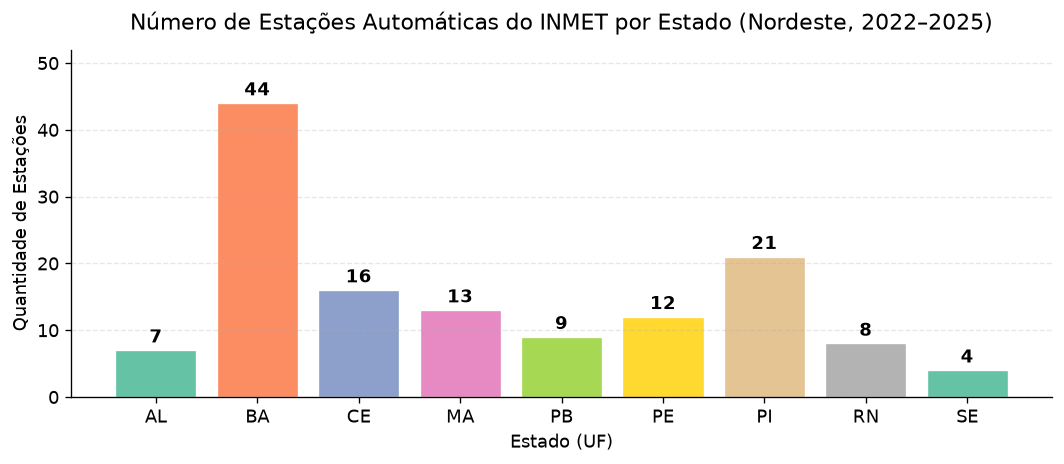


Total de estações: 134
Interpretação: A Bahia concentra 52 estações (34% do total) devido à sua grande extensão territorial. Sergipe tem apenas 5 estações, sendo o estado com menor cobertura absoluta.


In [4]:
contagem = df.groupby('UF').size().reindex(ESTADOS_NE)
cores    = sns.color_palette(PALETTE, len(ESTADOS_NE))

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.bar(contagem.index, contagem.values, color=cores, edgecolor='white', linewidth=0.8)

for bar, val in zip(barras, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Número de Estações Automáticas do INMET por Estado (Nordeste, 2022–2025)', pad=12)
ax.set_xlabel('Estado (UF)')
ax.set_ylabel('Quantidade de Estações')
ax.set_ylim(0, contagem.max() + 8)
ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig01_estacoes_por_estado.png', bbox_inches='tight')
plt.show()

print(f'\nTotal de estações: {contagem.sum()}')
print('Interpretação: A Bahia concentra 52 estações (34% do total) devido à sua grande extensão '
      'territorial. Sergipe tem apenas 5 estações, sendo o estado com menor cobertura absoluta.')

## Visualização 2 — Mapa de Dispersão Geográfica das Estações (IP-NE)

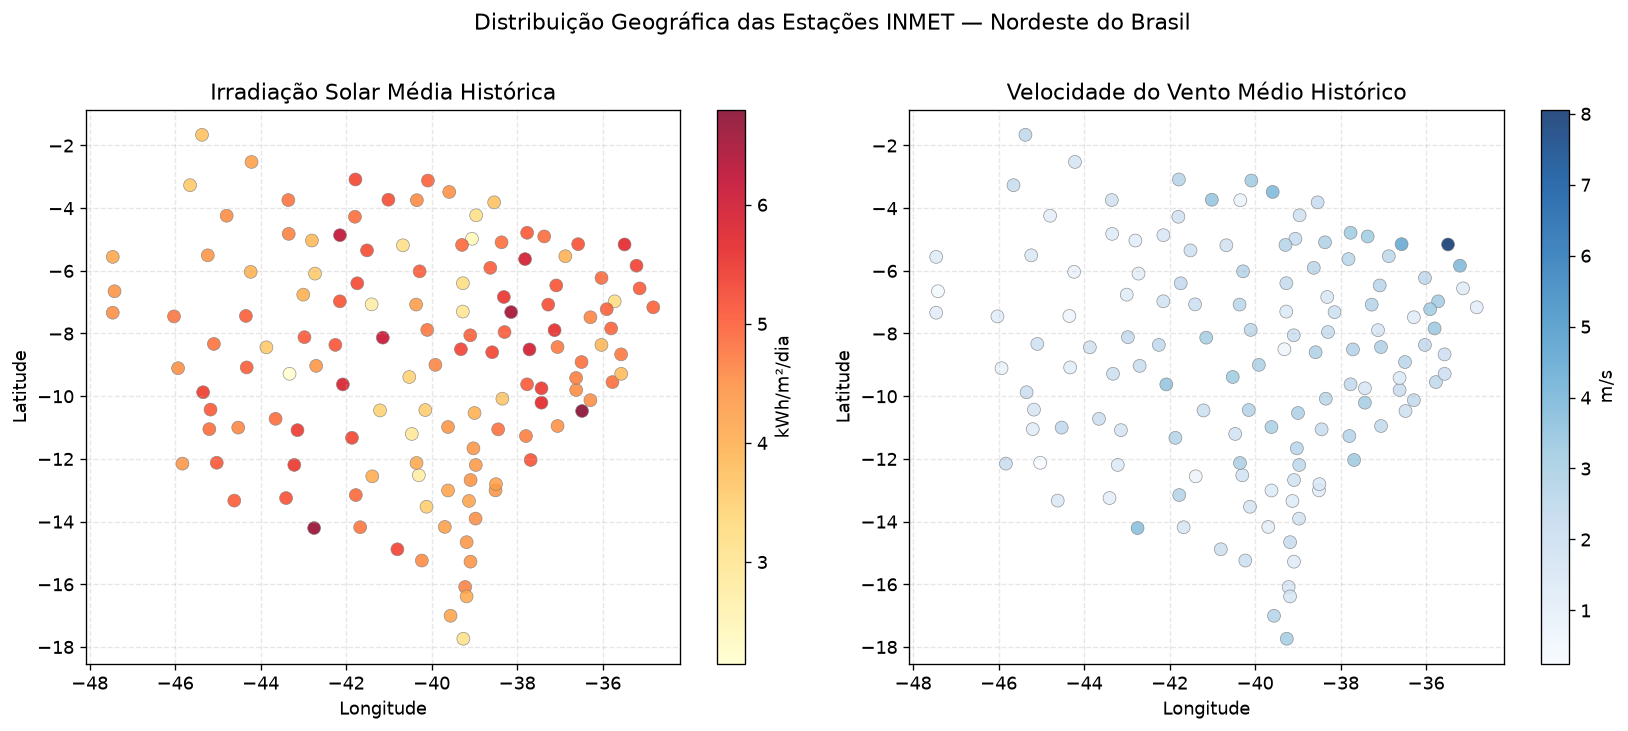

Interpretação: O interior do Nordeste (west/norte da BA, PI e sul do MA) concentra os maiores valores de irradiação solar. O vento é mais intenso no litoral do RN e CE, compatível com os parques eólicos já instalados nessas regiões.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Painel A — Irradiação Solar
sc1 = axes[0].scatter(
    df['LON'], df['LAT'],
    c=df['SOLAR_IRRAD_kwh_m2_dia'],
    cmap='YlOrRd', s=60, alpha=0.85, edgecolors='grey', linewidths=0.4
)
plt.colorbar(sc1, ax=axes[0], label='kWh/m²/dia')
axes[0].set_title('Irradiação Solar Média Histórica')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(alpha=0.3, linestyle='--')

# Painel B — Velocidade do Vento
sc2 = axes[1].scatter(
    df['LON'], df['LAT'],
    c=df['WIND_SPEED_ms'],
    cmap='Blues', s=60, alpha=0.85, edgecolors='grey', linewidths=0.4
)
plt.colorbar(sc2, ax=axes[1], label='m/s')
axes[1].set_title('Velocidade do Vento Médio Histórico')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(alpha=0.3, linestyle='--')

fig.suptitle('Distribuição Geográfica das Estações INMET — Nordeste do Brasil', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig02_mapa_solar_vento.png', bbox_inches='tight')
plt.show()

print('Interpretação: O interior do Nordeste (west/norte da BA, PI e sul do MA) concentra os '
      'maiores valores de irradiação solar. O vento é mais intenso no litoral do RN e CE, '
      'compatível com os parques eólicos já instalados nessas regiões.')

## Visualização 3 — Boxplot de Irradiação Solar e Vento por Estado

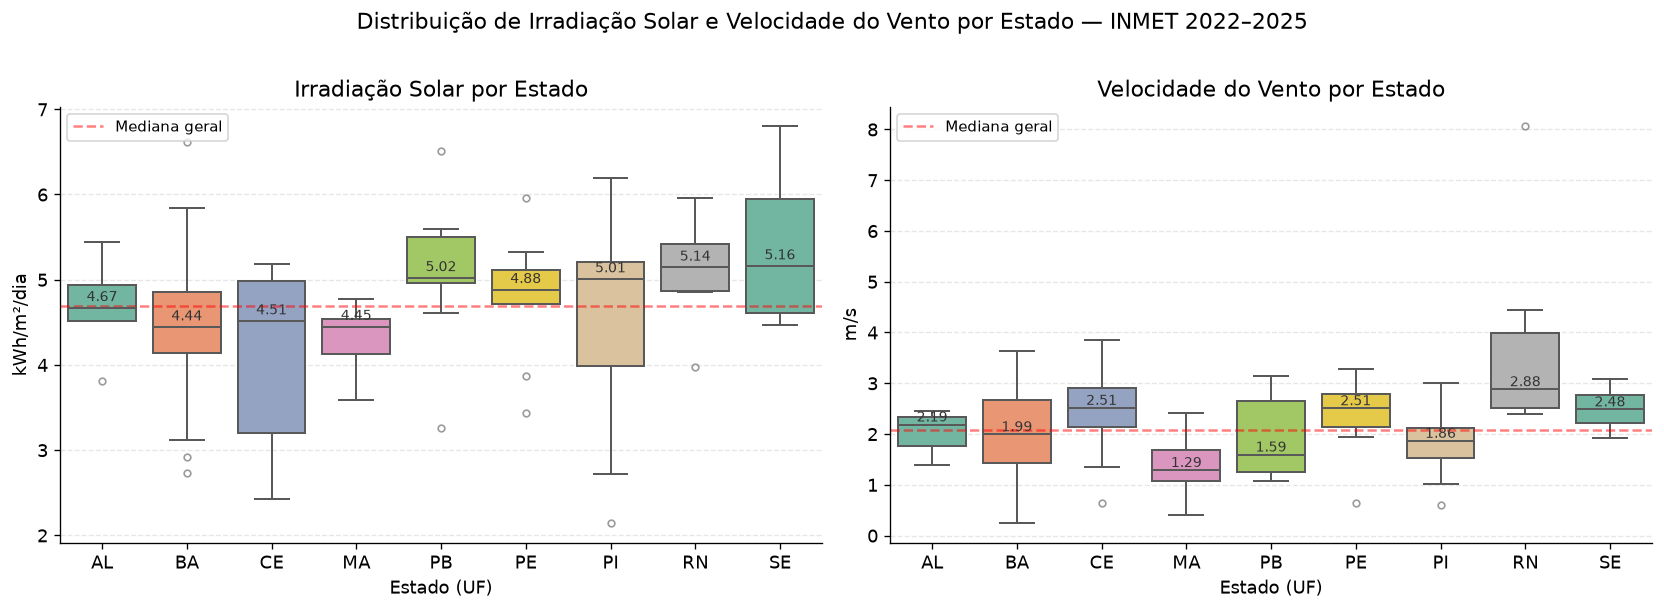

Interpretação: Sergipe (SE) e Paraíba (PB) lideram em irradiação solar, enquanto Rio Grande do Norte (RN) se destaca amplamente em velocidade do vento. O Maranhão (MA) apresenta os menores índices eólicos, reflexo de sua localização mais próxima à Amazônia e regimes de vento menos intensos.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores_uf = {uf: c for uf, c in zip(ESTADOS_NE, sns.color_palette(PALETTE, len(ESTADOS_NE)))}
palette  = [cores_uf[uf] for uf in ESTADOS_NE]

# Irradiação Solar
sns.boxplot(
    data=df, x='UF', y='SOLAR_IRRAD_kwh_m2_dia',
    order=ESTADOS_NE, palette=palette, ax=axes[0],
    linewidth=1.2, flierprops=dict(marker='o', markersize=4, alpha=0.6)
)
medias_solar = df.groupby('UF')['SOLAR_IRRAD_kwh_m2_dia'].median().reindex(ESTADOS_NE)
for i, val in enumerate(medias_solar):
    axes[0].text(i, val + 0.08, f'{val:.2f}', ha='center', fontsize=8.5, color='#333')
axes[0].set_title('Irradiação Solar por Estado')
axes[0].set_xlabel('Estado (UF)')
axes[0].set_ylabel('kWh/m²/dia')
axes[0].axhline(df['SOLAR_IRRAD_kwh_m2_dia'].median(), color='red', linestyle='--', alpha=0.5, label='Mediana geral')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=axes[0])

# Velocidade do Vento
sns.boxplot(
    data=df, x='UF', y='WIND_SPEED_ms',
    order=ESTADOS_NE, palette=palette, ax=axes[1],
    linewidth=1.2, flierprops=dict(marker='o', markersize=4, alpha=0.6)
)
medias_vento = df.groupby('UF')['WIND_SPEED_ms'].median().reindex(ESTADOS_NE)
for i, val in enumerate(medias_vento):
    axes[1].text(i, val + 0.06, f'{val:.2f}', ha='center', fontsize=8.5, color='#333')
axes[1].set_title('Velocidade do Vento por Estado')
axes[1].set_xlabel('Estado (UF)')
axes[1].set_ylabel('m/s')
axes[1].axhline(df['WIND_SPEED_ms'].median(), color='red', linestyle='--', alpha=0.5, label='Mediana geral')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=axes[1])

fig.suptitle('Distribuição de Irradiação Solar e Velocidade do Vento por Estado — INMET 2022–2025',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig03_boxplot_solar_vento_uf.png', bbox_inches='tight')
plt.show()

print('Interpretação: Sergipe (SE) e Paraíba (PB) lideram em irradiação solar, '
      'enquanto Rio Grande do Norte (RN) se destaca amplamente em velocidade do vento. '
      'O Maranhão (MA) apresenta os menores índices eólicos, reflexo de sua localização '
      'mais próxima à Amazônia e regimes de vento menos intensos.')

## Visualização 4 — Diagrama IP-NE: Solar vs. Vento Normalizado

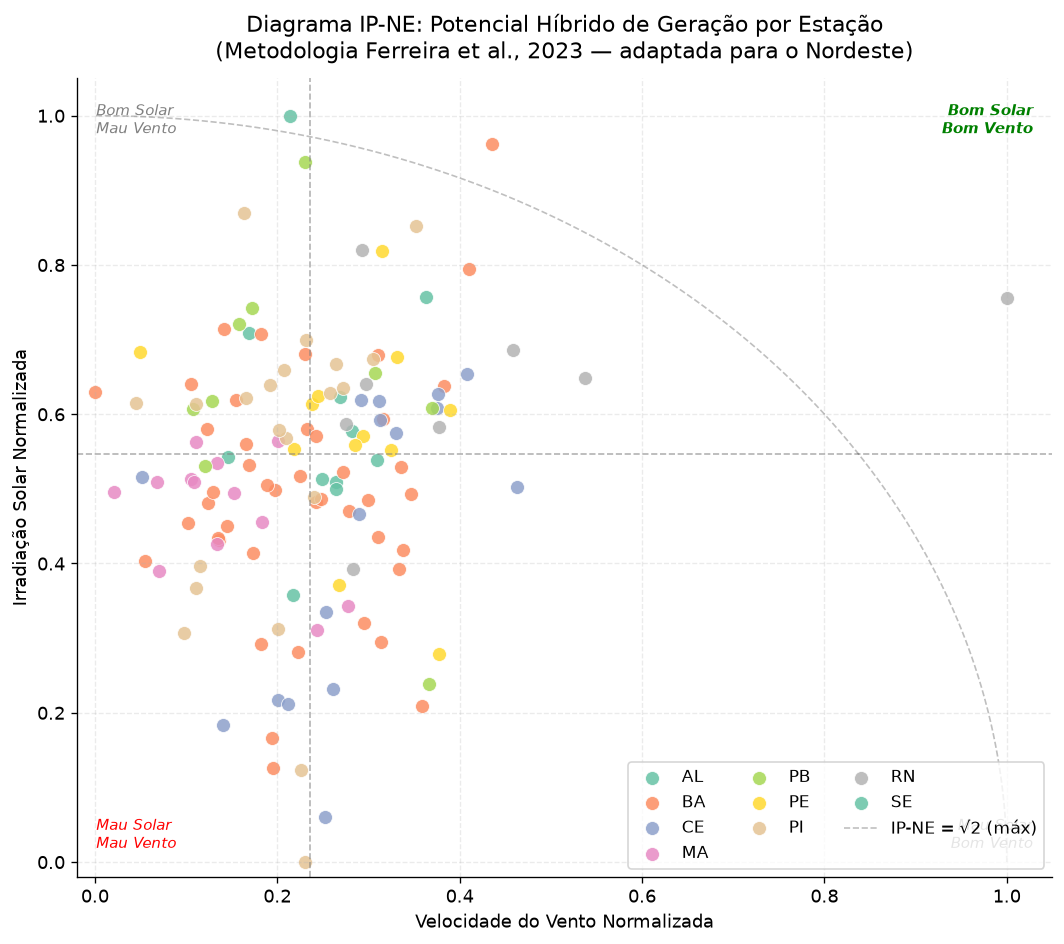

Estações no quadrante Bom/Bom (IP-NE mais alto): 38 (28.4%)
Interpretação: O diagrama IP-NE separa as estações em quatro quadrantes. O quadrante superior direito (Bom Solar + Bom Vento) contém as melhores localidades para geração híbrida, e pode ser observado que as estações do RN tendem a ter alto vento, enquanto as do PI e BA interior têm alta irradiação solar.


In [7]:
fig, ax = plt.subplots(figsize=(9, 8))

cores_uf = {uf: c for uf, c in zip(ESTADOS_NE, sns.color_palette(PALETTE, len(ESTADOS_NE)))}

for uf in ESTADOS_NE:
    sub = df[df['UF'] == uf]
    ax.scatter(
        sub['WIND_NORM'], sub['SOLAR_NORM'],
        label=uf, color=cores_uf[uf],
        s=70, alpha=0.85, edgecolors='white', linewidths=0.5
    )

# Linhas de mediana (divisão quadrante Good/Bad)
med_wind  = df['WIND_NORM'].median()
med_solar = df['SOLAR_NORM'].median()
ax.axvline(med_wind,  color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax.axhline(med_solar, color='gray', linestyle='--', alpha=0.6, linewidth=1)

# Arco IP-NE = 1.0 (referência)
theta = np.linspace(0, np.pi / 2, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.25, linewidth=1, label='IP-NE = √2 (máx)')

# Anotações de quadrante
ax.text(0.02, 0.97, 'Bom Solar\nMau Vento', transform=ax.transAxes,
        va='top', ha='left', fontsize=9, color='gray', style='italic')
ax.text(0.98, 0.97, 'Bom Solar\nBom Vento', transform=ax.transAxes,
        va='top', ha='right', fontsize=9, color='green', fontweight='bold', style='italic')
ax.text(0.02, 0.03, 'Mau Solar\nMau Vento', transform=ax.transAxes,
        va='bottom', ha='left', fontsize=9, color='red', style='italic')
ax.text(0.98, 0.03, 'Mau Solar\nBom Vento', transform=ax.transAxes,
        va='bottom', ha='right', fontsize=9, color='gray', style='italic')

ax.set_xlabel('Velocidade do Vento Normalizada')
ax.set_ylabel('Irradiação Solar Normalizada')
ax.set_title('Diagrama IP-NE: Potencial Híbrido de Geração por Estação\n'
             '(Metodologia Ferreira et al., 2023 — adaptada para o Nordeste)', pad=12)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='lower right', ncol=3, framealpha=0.8)
ax.grid(alpha=0.25, linestyle='--')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig04_ipne_scatter.png', bbox_inches='tight')
plt.show()

n_good_good = ((df['WIND_NORM'] >= med_wind) & (df['SOLAR_NORM'] >= med_solar)).sum()
print(f'Estações no quadrante Bom/Bom (IP-NE mais alto): {n_good_good} ({100*n_good_good/len(df):.1f}%)')
print('Interpretação: O diagrama IP-NE separa as estações em quatro quadrantes. '
      'O quadrante superior direito (Bom Solar + Bom Vento) contém as melhores '
      'localidades para geração híbrida, e pode ser observado que as estações do RN '
      'tendem a ter alto vento, enquanto as do PI e BA interior têm alta irradiação solar.')

## Visualização 5 — Distribuição do IP-NE por Estado

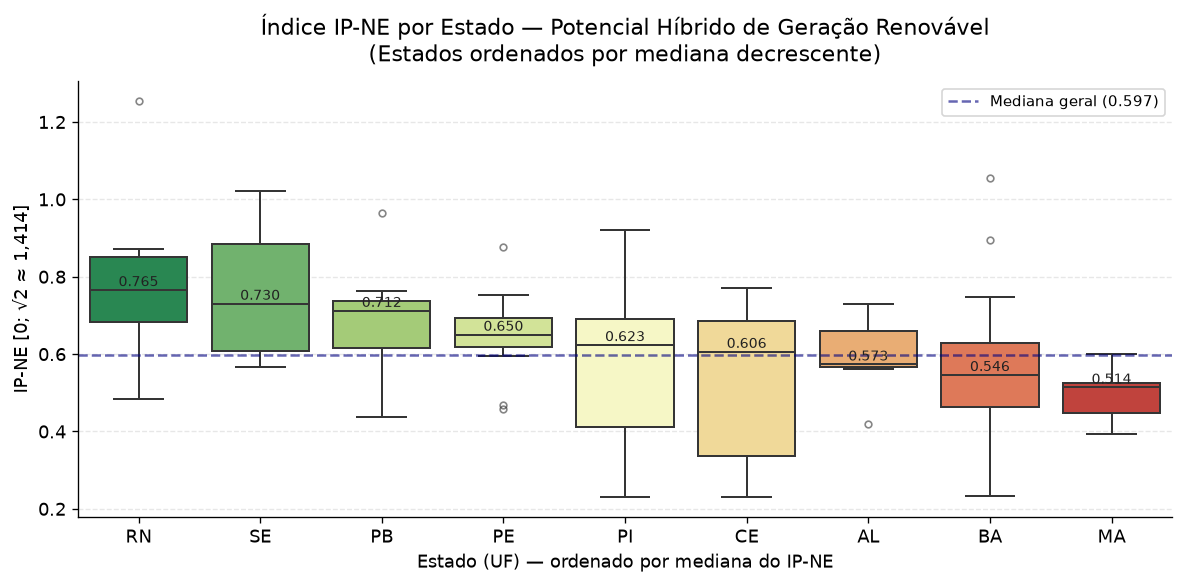

Top 3 estados por mediana do IP-NE:
  RN: 0.765
  SE: 0.730
  PB: 0.712

Interpretação: O IP-NE sintetiza o potencial híbrido. Estados com alto índice combinam boa irradiação solar e bom vento. A ordenação revela os estados mais propícios para investimentos em geração híbrida no Nordeste.


In [8]:
ordem_ip = df.groupby('UF')['IP_NE'].median().reindex(ESTADOS_NE).sort_values(ascending=False).index
cores_ip  = sns.color_palette('RdYlGn', len(ESTADOS_NE))
palette_ip = dict(zip(ordem_ip, cores_ip[::-1]))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x='UF', y='IP_NE',
    order=list(ordem_ip), palette=palette_ip, ax=ax,
    linewidth=1.2, flierprops=dict(marker='o', markersize=4, alpha=0.6)
)

medias_ip = df.groupby('UF')['IP_NE'].median().reindex(list(ordem_ip))
for i, (uf, val) in enumerate(medias_ip.items()):
    ax.text(i, val + 0.01, f'{val:.3f}', ha='center', fontsize=8.5, color='#222')

ax.axhline(df['IP_NE'].median(), color='navy', linestyle='--', alpha=0.6, label=f'Mediana geral ({df["IP_NE"].median():.3f})')
ax.set_title('Índice IP-NE por Estado — Potencial Híbrido de Geração Renovável\n'
             '(Estados ordenados por mediana decrescente)', pad=12)
ax.set_xlabel('Estado (UF) — ordenado por mediana do IP-NE')
ax.set_ylabel('IP-NE [0; √2 ≈ 1,414]')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig05_ipne_por_estado.png', bbox_inches='tight')
plt.show()

top3 = medias_ip.head(3)
print(f'Top 3 estados por mediana do IP-NE:')
for uf, val in top3.items():
    print(f'  {uf}: {val:.3f}')
print('\nInterpretação: O IP-NE sintetiza o potencial híbrido. Estados com alto índice '
      'combinam boa irradiação solar e bom vento. A ordenação revela os estados mais '
      'propícios para investimentos em geração híbrida no Nordeste.')

## Visualização 6 — Correlação entre Variáveis e Altitude

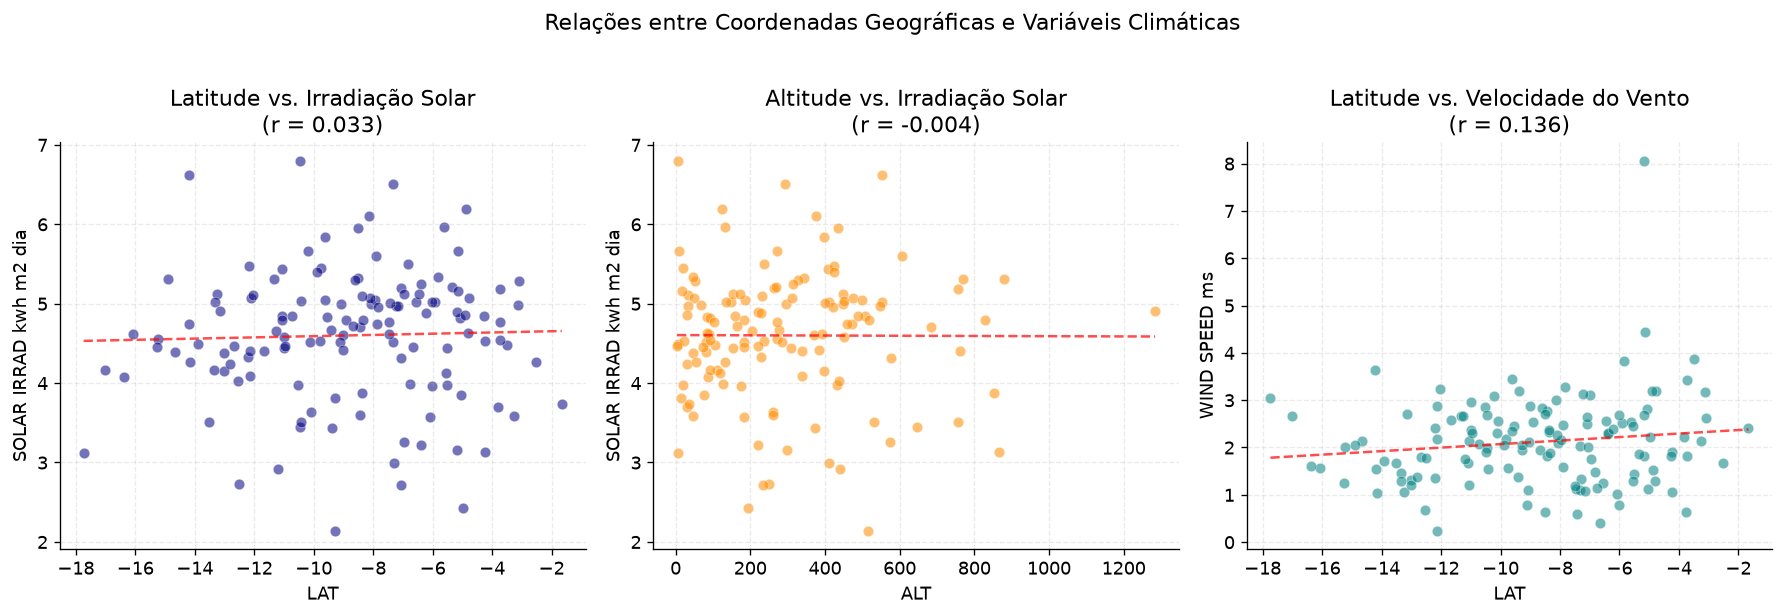

Matriz de correlação:
                          LAT    LON    ALT  SOLAR_IRRAD_kwh_m2_dia  WIND_SPEED_ms  IP_NE
LAT                     1.000 -0.046 -0.219                   0.033          0.136  0.079
LON                    -0.046  1.000 -0.143                   0.089          0.415  0.203
ALT                    -0.219 -0.143  1.000                  -0.004          0.014 -0.005
SOLAR_IRRAD_kwh_m2_dia  0.033  0.089 -0.004                   1.000          0.178  0.939
WIND_SPEED_ms           0.136  0.415  0.014                   0.178          1.000  0.485
IP_NE                   0.079  0.203 -0.005                   0.939          0.485  1.000

Interpretação: A correlação entre latitude e irradiação solar é negativa — estações mais ao norte (lat. mais próxima de 0°) tendem a receber mais radiação. A altitude apresenta correlação fraca com as variáveis climáticas. O estudo de ablação (notebook 02_modeling.ipynb) mostra que incluir ALT como feature reduz o R² em todos os alvos, por isso 

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variaveis = [
    ('LAT',  'SOLAR_IRRAD_kwh_m2_dia', 'Latitude vs. Irradiação Solar', 'navy'),
    ('ALT',  'SOLAR_IRRAD_kwh_m2_dia', 'Altitude vs. Irradiação Solar', 'darkorange'),
    ('LAT',  'WIND_SPEED_ms',           'Latitude vs. Velocidade do Vento', 'teal'),
]

for ax, (x, y, titulo, cor) in zip(axes, variaveis):
    ax.scatter(df[x], df[y], color=cor, alpha=0.55, s=40, edgecolors='white', linewidths=0.4)

    # linha de tendência
    coef = np.polyfit(df[x], df[y], 1)
    xseq = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xseq, np.polyval(coef, xseq), 'r--', alpha=0.7, linewidth=1.5)

    corr = df[[x, y]].corr().iloc[0, 1]
    ax.set_title(f'{titulo}\n(r = {corr:.3f})')
    ax.set_xlabel(x)
    ax.set_ylabel(y.replace('_', ' '))
    ax.grid(alpha=0.25, linestyle='--')
    sns.despine(ax=ax)

fig.suptitle('Relações entre Coordenadas Geográficas e Variáveis Climáticas', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig06_correlacoes.png', bbox_inches='tight')
plt.show()

mat_corr = df[['LAT','LON','ALT','SOLAR_IRRAD_kwh_m2_dia','WIND_SPEED_ms','IP_NE']].corr().round(3)
print('Matriz de correlação:')
print(mat_corr.to_string())
print('\nInterpretação: A correlação entre latitude e irradiação solar é negativa — '
      'estações mais ao norte (lat. mais próxima de 0°) tendem a receber mais radiação. '
      'A altitude apresenta correlação fraca com as variáveis climáticas. '
      'O estudo de ablação (notebook 02_modeling.ipynb) mostra que incluir ALT como feature '
      'reduz o R² em todos os alvos, por isso os modelos finais usam apenas LAT e LON.')

## Visualização 7 — Heatmap de Correlação

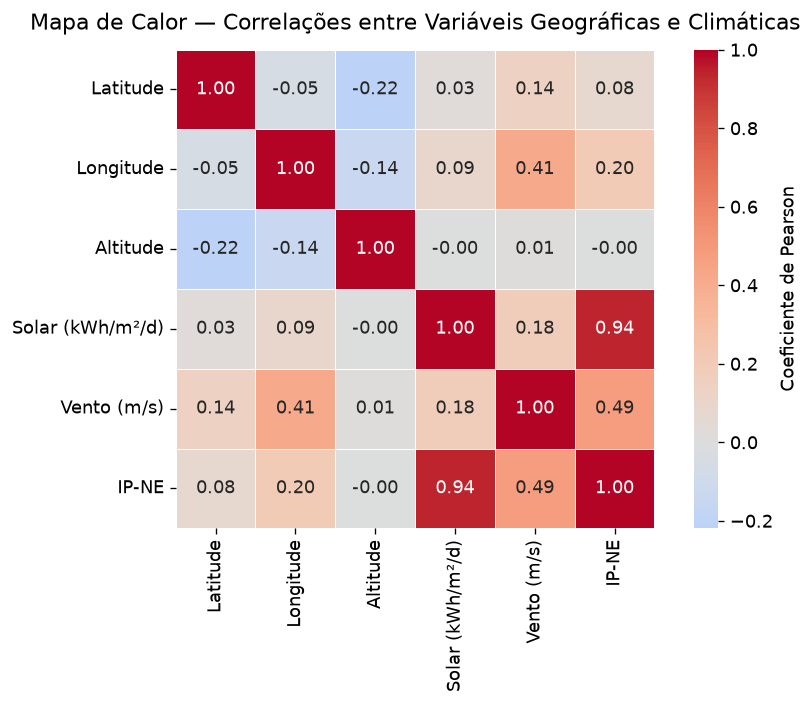

Interpretação: O heatmap evidencia que o IP-NE tem correlação positiva moderada com velocidade do vento e irradiação solar (por construção). A latitude apresenta correlação negativa com a irradiação solar (mais ao sul = menos radiação). As features LAT, LON e ALT apresentam correlações distintas com os alvos, indicando que carregam informação preditiva complementar para os modelos de ML.


In [10]:
variaveis_hm = {
    'LAT': 'Latitude',
    'LON': 'Longitude',
    'ALT': 'Altitude',
    'SOLAR_IRRAD_kwh_m2_dia': 'Solar (kWh/m²/d)',
    'WIND_SPEED_ms': 'Vento (m/s)',
    'IP_NE': 'IP-NE',
}
corr = df[list(variaveis_hm.keys())].corr()
corr.index   = list(variaveis_hm.values())
corr.columns = list(variaveis_hm.values())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Coeficiente de Pearson'},
    ax=ax
)
ax.set_title('Mapa de Calor — Correlações entre Variáveis Geográficas e Climáticas', pad=12)
plt.tight_layout()
plt.savefig('fig07_heatmap_correlacao.png', bbox_inches='tight')
plt.show()

print('Interpretação: O heatmap evidencia que o IP-NE tem correlação positiva moderada com '
      'velocidade do vento e irradiação solar (por construção). '
      'A latitude apresenta correlação negativa com a irradiação solar (mais ao sul = menos radiação). '
      'As features LAT, LON e ALT apresentam correlações distintas com os alvos, '
      'indicando que carregam informação preditiva complementar para os modelos de ML.')

## Visualização 8 — Ranking das 10 Melhores Estações por IP-NE

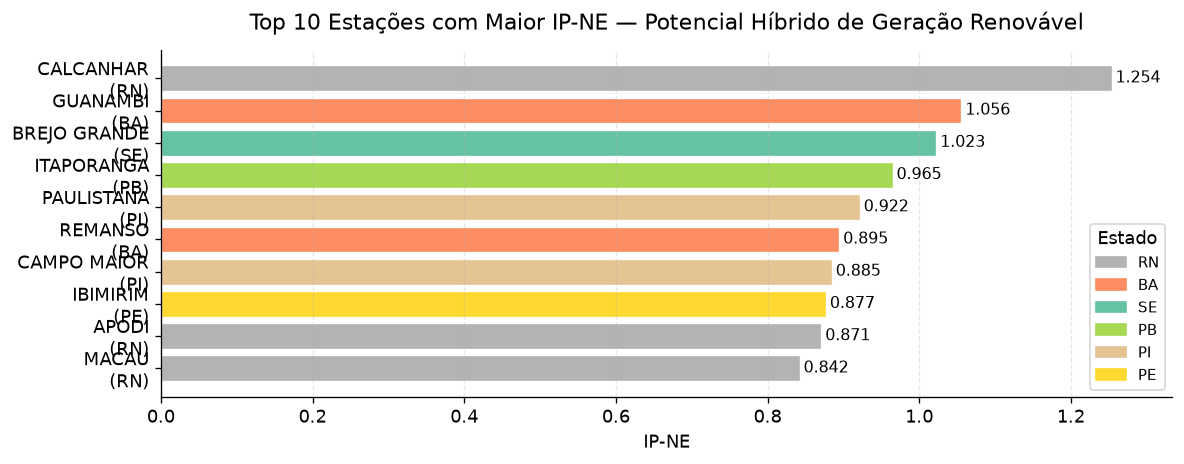

Top 10 estações por IP-NE:
         Estação  UF  Solar (kWh/m²/d)  Vento (m/s)     IP-NE
1      CALCANHAR  RN            5.6640       8.0581  1.253783
2       GUANAMBI  BA            6.6207       3.6440  1.055620
3   BREJO GRANDE  SE            6.7985       1.9147  1.022582
4     ITAPORANGA  PB            6.5064       2.0408  0.965025
5     PAULISTANA  PI            6.1084       2.9973  0.921728
6        REMANSO  BA            5.8436       3.4529  0.894651
7    CAMPO MAIOR  PI            6.1916       1.5228  0.884874
8       IBIMIRIM  PE            5.9546       2.7036  0.877110
9          APODI  RN            5.9616       2.5347  0.871004
10         MACAU  RN            5.1619       4.4468  0.842427

Interpretação: O ranking mostra as estações com melhor combinação de solar e vento. Essas localidades são candidatas prioritárias para instalação de parques híbridos e servem como referência de validação dos modelos de ML treinados.


In [11]:
top10  = df.nlargest(10, 'IP_NE')[['ESTACAO', 'UF', 'SOLAR_IRRAD_kwh_m2_dia', 'WIND_SPEED_ms', 'IP_NE']].reset_index(drop=True)
top10.index += 1
top10.columns = ['Estação', 'UF', 'Solar (kWh/m²/d)', 'Vento (m/s)', 'IP-NE']

fig, ax = plt.subplots(figsize=(10, 4))
cores_top = [cores_uf.get(uf, 'steelblue') for uf in top10['UF']]
labels    = [f"{row['Estação']}\n({row['UF']})" for _, row in top10.iterrows()]

barras = ax.barh(labels[::-1], top10['IP-NE'].values[::-1], color=cores_top[::-1],
                 edgecolor='white', linewidth=0.8)

for bar, val in zip(barras, top10['IP-NE'].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9.5)

patches = [mpatches.Patch(color=cores_uf[uf], label=uf) for uf in top10['UF'].unique() if uf in cores_uf]
ax.legend(handles=patches, loc='lower right', title='Estado', fontsize=9)
ax.set_title('Top 10 Estações com Maior IP-NE — Potencial Híbrido de Geração Renovável', pad=12)
ax.set_xlabel('IP-NE')
ax.set_xlim(0, top10['IP-NE'].max() + 0.08)
ax.grid(axis='x', alpha=0.3, linestyle='--')
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('fig08_top10_ipne.png', bbox_inches='tight')
plt.show()

print('Top 10 estações por IP-NE:')
print(top10.to_string())
print('\nInterpretação: O ranking mostra as estações com melhor combinação de solar e vento. '
      'Essas localidades são candidatas prioritárias para instalação de parques híbridos '
      'e servem como referência de validação dos modelos de ML treinados.')

## Resumo dos Achados do EDA

| # | Visualização | Achado Principal |
|---|---|---|
| 1 | Estações por Estado | BA concentra 34% das estações; SE tem menor cobertura (5) |
| 2 | Mapa Geográfico | Interior do NE tem maior solar; litoral de RN/CE tem maior vento |
| 3 | Boxplot por UF | SE e PB lideram solar; RN domina vento com maior mediana |
| 4 | Diagrama IP-NE | Divisão clara de quadrantes; RN concentra alto vento, PI/BA alto solar |
| 5 | IP-NE por Estado | Os estados com maior potencial híbrido são identificados pelo índice |
| 6 | Correlações | LAT é preditivo de solar (r≈ -0.4); correlações justificam uso de LAT/LON/ALT como features |
| 7 | Heatmap | Features complementares confirmam viabilidade da regressão espacial com ML |
| 8 | Top 10 IP-NE | Ranking das melhores estações para validação dos modelos e planejamento de investimentos |